In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,RandomRotation,RandomZoom,RandomContrast,RandomTranslation,GlobalAveragePooling2D
from  sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
(train_ds, test_ds), ds_info = tfds.load(
    "svhn_cropped",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

In [7]:
print(ds_info)

tfds.core.DatasetInfo(
    name='svhn_cropped',
    full_name='svhn_cropped/3.1.0',
    description="""
    The Street View House Numbers (SVHN) Dataset is an image digit recognition
    dataset of over 600,000 digit images coming from real world data. Images are
    cropped to 32x32.
    """,
    homepage='http://ufldl.stanford.edu/housenumbers/',
    data_dir='/root/tensorflow_datasets/svhn_cropped/3.1.0',
    file_format=tfrecord,
    download_size=1.47 GiB,
    dataset_size=1.09 GiB,
    features=FeaturesDict({
        'id': Text(shape=(), dtype=string),
        'image': Image(shape=(32, 32, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'extra': <SplitInfo num_examples=531131, num_shards=8>,
        'test': <SplitInfo num_examples=26032, num_shards=1>,
        'train': <SplitInfo num_examples=73257, num_shards=1>

In [8]:
print(ds_info.features)
print(ds_info.splits)

FeaturesDict({
    'id': Text(shape=(), dtype=string),
    'image': Image(shape=(32, 32, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
})
{'train': <SplitInfo num_examples=73257, num_shards=1>, 'test': <SplitInfo num_examples=26032, num_shards=1>, 'extra': <SplitInfo num_examples=531131, num_shards=8>}


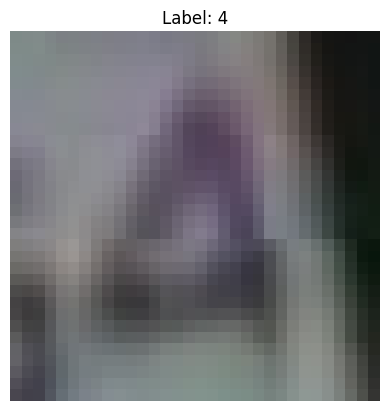

In [9]:
for image,label in train_ds.take(1):
    plt.imshow(image)
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
    plt.show()

In [35]:
for image, label in train_ds.take(1):
  print(image.shape)

(64, 32, 32, 3)


In [2]:
def preprocess(image,label):
  image = tf.cast(image,tf.float32) /255.0
  return image,label
#tf.cast(image, tf.float32)Converts the image from:uint8 → float32
train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)
#The map() function applies the preprocessing function to every image in the dataset.

train_ds = train_ds.shuffle(10000)
#Why Shuffle? Without shuffling:111111222222333333444444The model learns in a fixed order.After shuffling:314251426315241352..
#Randomizing the order improves generalization and helps prevent the model from learning unwanted patterns.
BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

'''Faster training
Better GPU utilization
More stable gradient updates'''

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
#This keeps the GPU busy and speeds up training.

In [3]:
for image,label in train_ds.take(1):
  print("Image Shape:",image.shape)
  print("Label Shape:",label.shape)
  print("Pixel Range :", tf.reduce_min(image).numpy(), "to", tf.reduce_max(image).numpy())

Image Shape: (64, 32, 32, 3)
Label Shape: (64,)
Pixel Range : 0.0 to 1.0


In [4]:
model = Sequential([
    tf.keras.Input(shape=(32, 32, 3), dtype=tf.float32),
    Conv2D(32,(3,3),padding = 'same',activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),padding = 'same',activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),padding = 'same',activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(train_ds,epochs = 30,validation_data = test_ds,callbacks = EarlyStopping())

Epoch 1/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.3968 - loss: 1.6944 - val_accuracy: 0.7399 - val_loss: 0.8687
Epoch 2/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6883 - loss: 0.9440 - val_accuracy: 0.8383 - val_loss: 0.5902
Epoch 3/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7598 - loss: 0.7725 - val_accuracy: 0.8578 - val_loss: 0.5011
Epoch 4/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7875 - loss: 0.6887 - val_accuracy: 0.8671 - val_loss: 0.4754
Epoch 5/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8072 - loss: 0.6372 - val_accuracy: 0.8652 - val_loss: 0.4692
Epoch 6/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8232 - loss: 0.5896 - val_accuracy: 0.8733 - val_loss: 0.4572
Epoch 7/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8365 - loss: 0.5468 - val_accuracy: 0.8821 - val_loss: 0.4238
Epoch 8/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8492 -

In [5]:
test_loss,test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8812 - loss: 0.4241
Test Accuracy: 88.12%


In [6]:
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

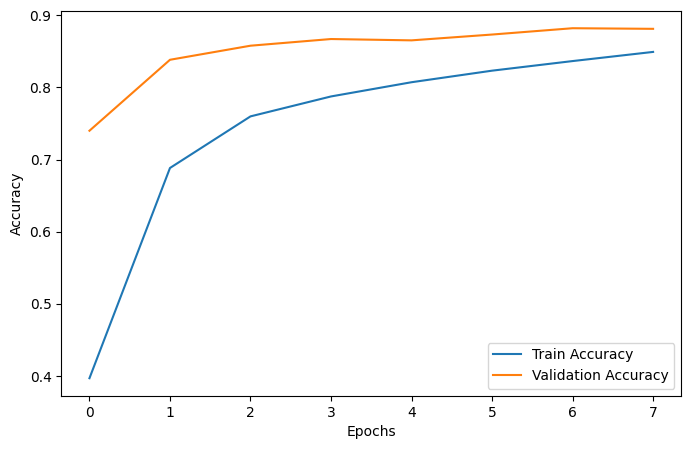

In [7]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label ='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

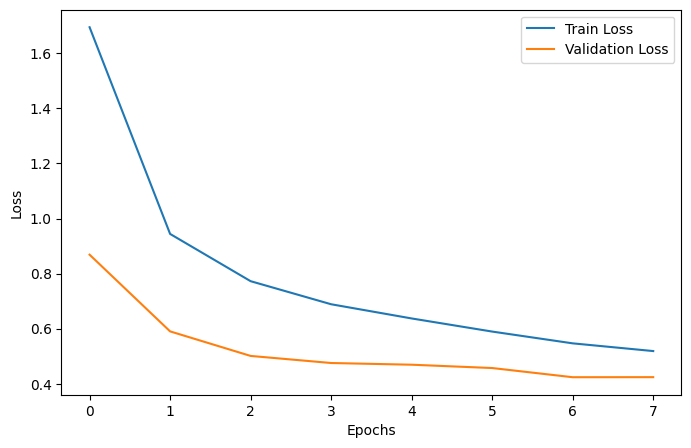

In [8]:
plt.figure(figsize = (8,5))
plt.plot(history.history['loss'],label = 'Train Loss')
plt.plot(history.history['val_loss'],label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
if(np.average(train_accuracy) - np.average(val_accuracy)<0.5):
    print("Good Fit")
else:
    print("Overfit")

Good Fit


In [10]:
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions,axis = 1)
print("Predicted:")
print(predicted_labels[:10])
print("Actual:")
actual_labels = np.concatenate([y for x, y in test_ds], axis=0)
print(actual_labels[:10])

407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Predicted:
[2 7 2 4 4 2 6 2 3 1]
Actual:
[2 7 2 4 4 2 6 2 3 1]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step 


<Figure size 1000x1000 with 0 Axes>

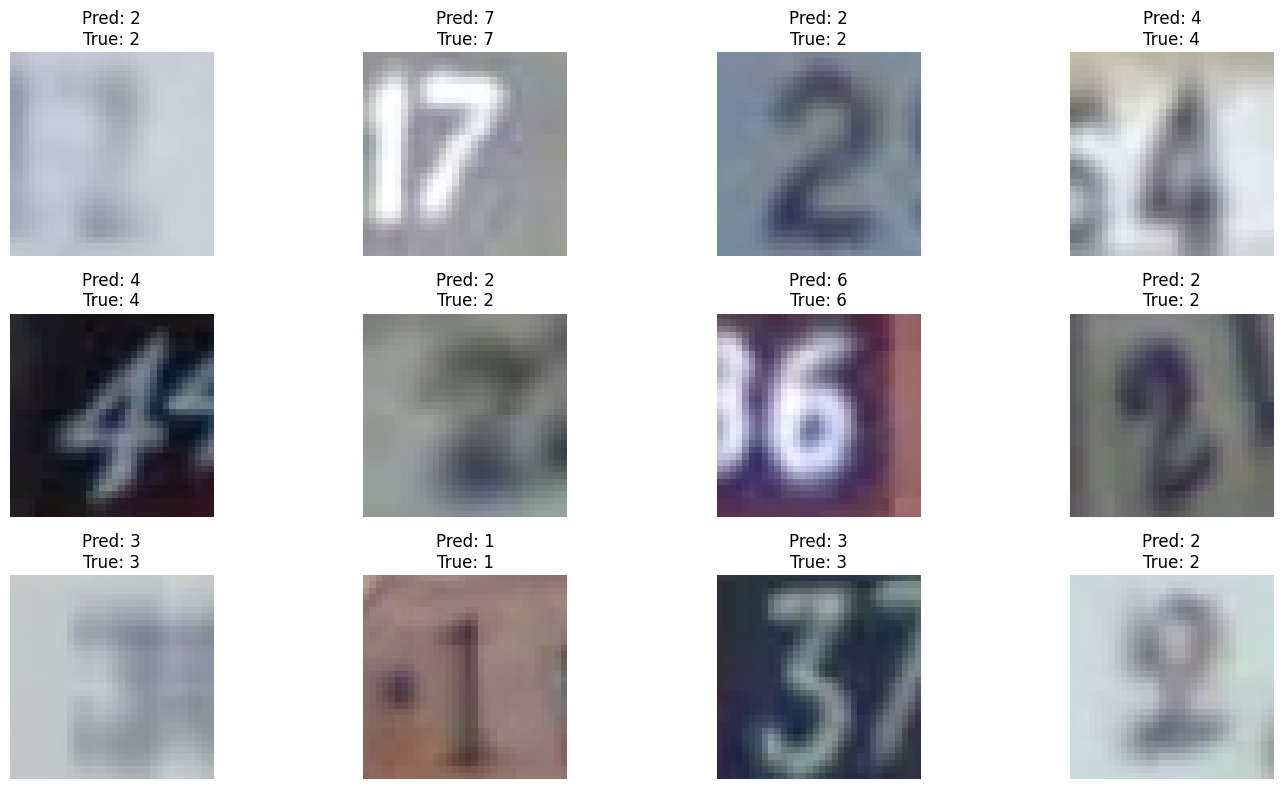

In [11]:
images,labels = next(iter(test_ds))
preds = model.predict(images)
preds = np.argmax(preds,axis = 1)
plt.figure(figsize = (10,10))
plt.figure(figsize=(15,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(images[i])
  plt.title(f"Pred: {preds[i]}\nTrue: {labels[i].numpy()}")
  plt.axis("off")
plt.tight_layout()
plt.show()

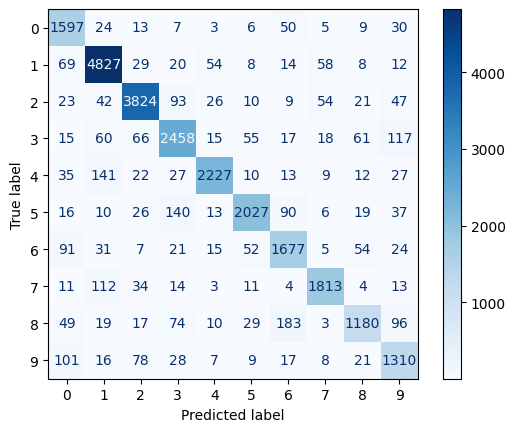

In [12]:
cm = confusion_matrix(actual_labels,predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')
plt.show()

In [13]:
print(classification_report(actual_labels,predicted_labels))

              precision    recall  f1-score   support

           0       0.80      0.92      0.85      1744
           1       0.91      0.95      0.93      5099
           2       0.93      0.92      0.93      4149
           3       0.85      0.85      0.85      2882
           4       0.94      0.88      0.91      2523
           5       0.91      0.85      0.88      2384
           6       0.81      0.85      0.83      1977
           7       0.92      0.90      0.91      2019
           8       0.85      0.71      0.77      1660
           9       0.76      0.82      0.79      1595

    accuracy                           0.88     26032
   macro avg       0.87      0.86      0.87     26032
weighted avg       0.88      0.88      0.88     26032



In [70]:
data_augmentation = Sequential([
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2),
    RandomTranslation(0.2,0.2)
])

In [71]:
dg_model = Sequential([
    tf.keras.Input(shape=(32, 32, 3), dtype=tf.float32),
    data_augmentation,
    Conv2D(16,(3,3),padding = 'same',activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(32,(3,3),padding = 'same',activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),padding = 'same',activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),padding = 'same',activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

dg_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

dg_history = dg_model.fit(train_ds,epochs = 30,validation_data = test_ds,callbacks = EarlyStopping())

Epoch 1/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.1914 - loss: 2.2231 - val_accuracy: 0.2990 - val_loss: 2.0120
Epoch 2/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.2923 - loss: 1.9795 - val_accuracy: 0.4295 - val_loss: 1.6234
Epoch 3/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.4003 - loss: 1.7034 - val_accuracy: 0.5975 - val_loss: 1.2439
Epoch 4/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.4914 - loss: 1.4939 - val_accuracy: 0.6502 - val_loss: 1.0648
Epoch 5/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.5398 - loss: 1.3568 - val_accuracy: 0.6839 - val_loss: 0.9471
Epoch 6/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.5724 - loss: 1.2697 - val_accuracy: 0.7101 - val_loss: 0.8820
Epoch 7/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.5953 - loss: 1.2103 - val_accuracy: 0.7271 - val_loss: 0.8585
Epoch 8/30
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.6185 -

In [72]:
test_loss,test_accuracy = dg_model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7863 - loss: 0.6978
Test Accuracy: 78.63%


In [73]:
train_accuracy = dg_history.history["accuracy"]
val_accuracy = dg_history.history["val_accuracy"]
train_loss = dg_history.history["loss"]
val_loss = dg_history.history["val_loss"]

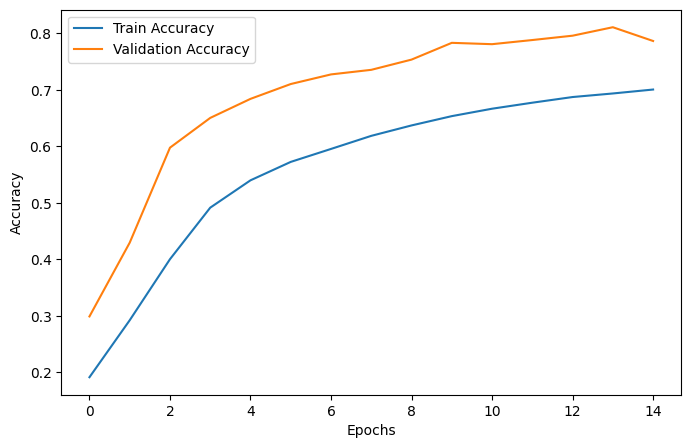

In [74]:
plt.figure(figsize=(8,5))
plt.plot(dg_history.history['accuracy'],label='Train Accuracy')
plt.plot(dg_history.history['val_accuracy'],label ='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

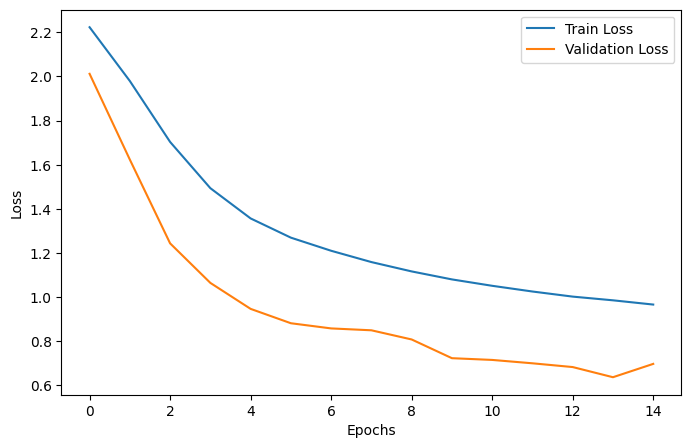

In [75]:
plt.figure(figsize = (8,5))
plt.plot(dg_history.history['loss'],label = 'Train Loss')
plt.plot(dg_history.history['val_loss'],label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [76]:
if(np.average(train_accuracy) - np.average(val_accuracy)<0.5):
    print("Good Fit")
else:
    print("Overfit")

Good Fit


In [77]:
dg_predictions = dg_model.predict(test_ds)
dg_predicted_labels = np.argmax(dg_predictions,axis = 1)
print("Predicted:")
print(predicted_labels[:10])
print("Actual:")
actual_labels = np.concatenate([y for x, y in test_ds], axis=0)
print(actual_labels[:10])

407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Predicted:
[2 7 2 4 4 2 6 2 5 1]
Actual:
[2 7 2 4 4 2 6 2 3 1]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


<Figure size 1000x1000 with 0 Axes>

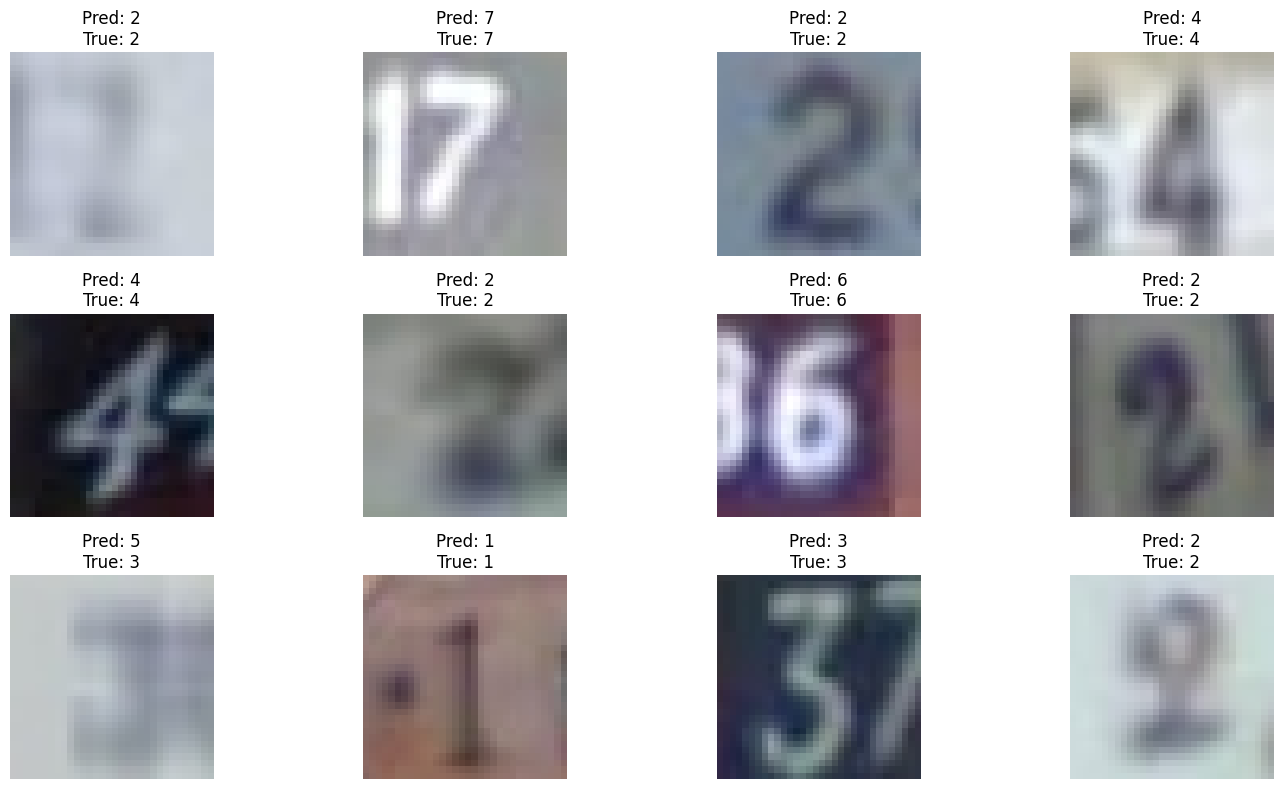

In [78]:
images,labels = next(iter(test_ds))
preds = dg_model.predict(images)
preds = np.argmax(preds,axis = 1)
plt.figure(figsize = (10,10))
plt.figure(figsize=(15,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(images[i])
  plt.title(f"Pred: {preds[i]}\nTrue: {labels[i].numpy()}")
  plt.axis("off")
plt.tight_layout()
plt.show()

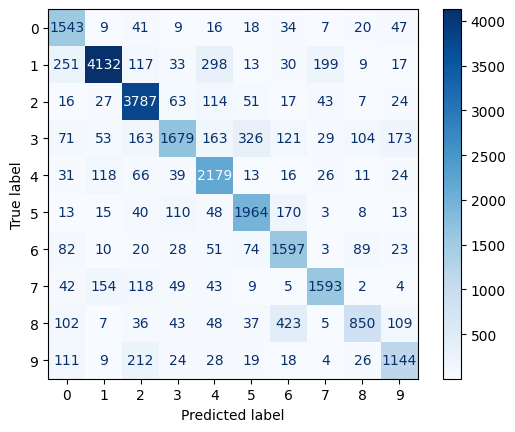

In [79]:
dg_cm = confusion_matrix(actual_labels,predicted_labels)
dg_disp = ConfusionMatrixDisplay(confusion_matrix=dg_cm)
dg_disp.plot(cmap = 'Blues')
plt.show()

In [80]:
print(classification_report(actual_labels,predicted_labels))

              precision    recall  f1-score   support

           0       0.68      0.88      0.77      1744
           1       0.91      0.81      0.86      5099
           2       0.82      0.91      0.87      4149
           3       0.81      0.58      0.68      2882
           4       0.73      0.86      0.79      2523
           5       0.78      0.82      0.80      2384
           6       0.66      0.81      0.72      1977
           7       0.83      0.79      0.81      2019
           8       0.75      0.51      0.61      1660
           9       0.72      0.72      0.72      1595

    accuracy                           0.79     26032
   macro avg       0.77      0.77      0.76     26032
weighted avg       0.79      0.79      0.78     26032



In [2]:
#Lets use Transfer Learning
from tensorflow.keras.applications import EfficientNetB0
IMG_SIZE = 160
BATCH_SIZE = 16


def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
    image = image / 255.0

    return image,label


train_ds = (
    train_ds
    .map(preprocess,num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(5000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


test_ds = (
    test_ds
    .map(preprocess,num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [3]:
for image,label in train_ds.take(1):
  print(image.shape)

(16, 160, 160, 3)


In [4]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(160,160,3)
)


base_model.trainable=False


ts_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])
ts_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ts_history = ts_model.fit(train_ds,epochs = 15,validation_data = test_ds)

Epoch 1/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 154s 27ms/step - accuracy: 0.1877 - loss: 2.2444 - val_accuracy: 0.1959 - val_loss: 2.2241
Epoch 2/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 101s 22ms/step - accuracy: 0.1892 - loss: 2.2367 - val_accuracy: 0.1959 - val_loss: 2.2238
Epoch 3/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 117s 25ms/step - accuracy: 0.1892 - loss: 2.2367 - val_accuracy: 0.1959 - val_loss: 2.2235
Epoch 4/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 101s 21ms/step - accuracy: 0.1892 - loss: 2.2366 - val_accuracy: 0.1959 - val_loss: 2.2238
Epoch 5/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 142s 22ms/step - accuracy: 0.1892 - loss: 2.2366 - val_accuracy: 0.1959 - val_loss: 2.2238
Epoch 6/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 141s 21ms/step - accuracy: 0.1892 - loss: 2.2367 - val_accuracy: 0.1959 - val_loss: 2.2238
Epoch 7/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 145s 22ms/step - accuracy: 0.1892 - loss: 2.2367 - val_accuracy: 0.1959 - val_loss: 2.2237
Epoch 8/15
4579/4579 ━━━━━━━━━━━━━━━━━━━━ 101s 22ms/step - accuracy: 